# Data Analysis (3): Pandas 3

In this `data_analysis_2` notebook we will concentrate on plotting data that is in a `pandas` dataframe:

## Contents 
1. Plotting

In [1]:
# Imports ...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/matthewjohnpayne/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# 3.1 : Basic Plotting

Here we start by generating some random data and then plotting each series 

This is very straighforward using pandas 

In [2]:
# Use numpy functionality to randomly generate an array (of size 1000*4) numbers drawn from a gaussian distribution
df = pd.DataFrame(np.random.randn(1000, 4), columns=list("ABCD"))
# Use pandas cumulative-summation function to sum each field
df = df.cumsum()
df.head(3)

,A,B,C,D
0,0.097285,-0.776872,-1.249539,0.176650
1,-0.279933,-1.155808,-2.235382,0.674736
2,0.294931,-1.197654,-2.426494,0.512874


<Axes: >

<Figure size 432x288 with 0 Axes>

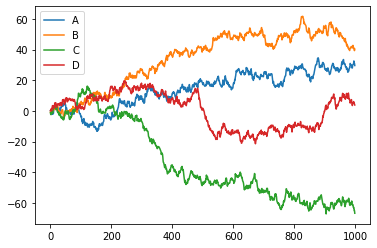

In [5]:
# Plot all data  
df.plot()

<Axes: >

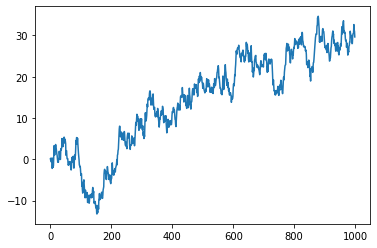

In [16]:
# Plot a single series 
df.A.plot()

# 3.2 : Scatter Plots

In the cells below we demonstrate the use of the `plot.scatter()` function to plot selected fields from a dataframe

We also demonstrate that formatting options can be passed in to this function as well 

In [26]:
# Read the"titanic" data set we used in `data_analysis_1`
titanic = pd.read_csv("https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv")
titanic.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


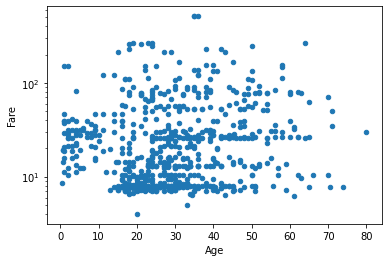

In [27]:
# Make a scatter plot of Age versus Fare 
# *** Note the use of the `logy=True` option ***
titanic.plot.scatter(x="Age", y="Fare", logy=True);


# Exercise 3(a) 

Take the merged dataframe from Exercise 2(a) in `data_analysis_2.ipynb` that was produced using the standard import method, producing a dataframe which contains only the 267 stars with mass measurements from both the `mass_midm.dat` & `mass_reddot.dat` files 

1. Make a scatter plot of `mass-db` versus `mass-r`
2. Identify the obvious odd/wrong point
3. Remove the odd/wrong point from the dataframe : See the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html) for `drop`
4. Replot the scatter plot of `mass-db` versus `mass-r` 

# 3.3 : Histograms & Cumulative Histograms

# *** Jen : I have started using the Gaussian / Normal distribution here ***
 - It's *not* fundamentally important to what I am trying to describe. 
 - Would it be better to use something else instead ? 

In [87]:
# Use numpy functionality to 
# randomly generate an array (of size 1000) numbers drawn from a gaussian distribution
#  - Note that each Gaussian is shift to be centered on 0, 2, 4, 6
df = pd.DataFrame(
    np.array( [ np.random.normal(loc=i*2, scale=1.0, size=1000) for i in range(4) ] ).T, 
    columns=list("ABCD"))

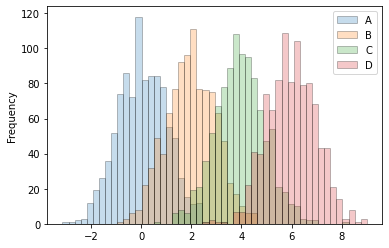

In [81]:
# Plot histograms using `plot.hist`
df.plot.hist(alpha=0.25, bins=50, edgecolor='k');

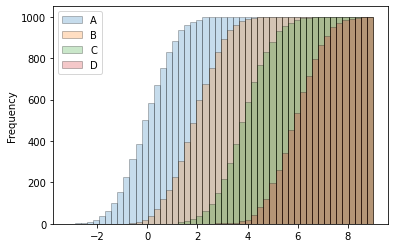

In [84]:
# If we pass the `cumulative=True` option, we get a cumulative histogram
df.plot.hist(alpha=0.25, bins=50, cumulative=True, edgecolor='k');

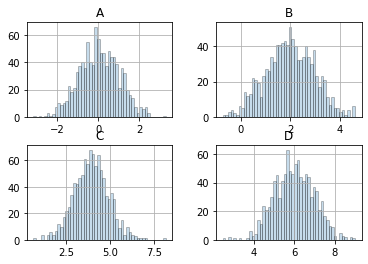

In [86]:
# If we omit `plot` and just do `df.hist`, then the behavior changes ...
# - The histograms now default to being plotted on 4 separate sub-plots 
df.hist(alpha=0.25, bins=50, edgecolor='k');

# Exercise 3(b) 

Use the `titanic` dataframe from above

1. Plot a histogram of the `Fare` field. Include a label on the x-axis
2. Plot a cumulative histogram of the `Fare` field. Include a label on the x-axis

# 3.4 : Scatter Matrix 

It is often useful to combine *scatter* plots and histograms/kernel-density plots in the same figure. 

The `scatter_matrix` plot can do this automatically. 

## 3.4.1 : Correlated Data
In this example below, we import data on the height & weight of a population of 25,000 18 year-olds  
(The data set, `SOCR-HeightWeight.csv` is taken from [http://socr.ucla.edu/docs/resources/SOCR_Data/SOCR_Data_Dinov_020108_HeightsWeights.html](http://socr.ucla.edu/docs/resources/SOCR_Data/SOCR_Data_Dinov_020108_HeightsWeights.html))

Then we plot the distribution of both using the `scatter_matrix` function

In [126]:
# Import the data 
df = pd.read_csv("SOCR-HeightWeight.csv")
df.drop(["Index"],axis=1,inplace=True)
df.head(3) 

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269


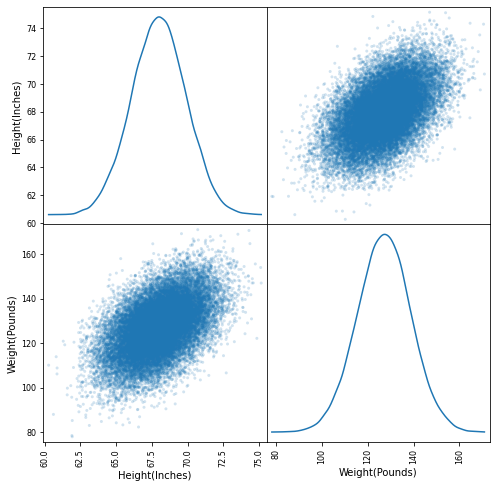

In [127]:
# Plot the distributions 
from pandas.plotting import scatter_matrix
_ = scatter_matrix(df, alpha=0.2, figsize=(8, 8), diagonal="kde")

In the example above, the histograms/kernel-density plots look like pretty good gaussian curves.

But the scatter plots are not circular, but rather are stretched out along the diagonal.

This tells us that there is some sort of **correlation**. 

I.e. **taller** people tend to be **heavier**


## 3.4.1 : Uncorrelated/Independent Data

We will now use the `scatter_matrix` function to plot some uncorrelated/independent data.

Let's start from the same height-weight dataframe as above. 
 - but then let's *delete* the weight data 
 - and replace it with some totally unrelated invented data 

In [131]:
# Read the data 
df = pd.read_csv("SOCR-HeightWeight.csv")
df.drop(["Index"],axis=1,inplace=True)
# Drop the "weight" data 
df.drop(["Weight(Pounds)"],axis=1,inplace=True)
# Use numpy to create some gaussian data and put it into a new field in our dataframe 
df["Invented"] = np.random.normal(loc=0, scale=1.0, size=len(df))
df.head(3)


,Height(Inches),Invented
0,65.78331,0.708226
1,71.51521,-0.723308
2,69.39874,1.137786


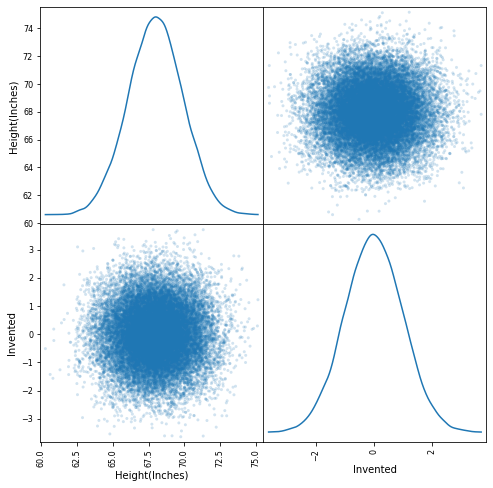

In [132]:
# Plot the distributions 
from pandas.plotting import scatter_matrix
_ = scatter_matrix(df, alpha=0.2, figsize=(8, 8), diagonal="kde")

In the example above, the histograms/kernel-density plots look like pretty good gaussian curves.

But the scatter plots are *circular*.

This tells us that there is **no**: the data are independent of one another. 


# Exercise 3(c) 

Use the `FatherSon.txt` data set (taken from [https://www.kaggle.com/datasets/abhilash04/fathersandsonheight](https://www.kaggle.com/datasets/abhilash04/fathersandsonheight))

1. Import it into a dataframe
2. Plot the data use `scatter_matrix`
3. Do the heights of the sons appear to be *independent* of the height of the father, or *correlated* ?